# Discharge reconstruction during data gaps 2022-2023

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

lajara_2022 = pd.read_csv("la_jara/discharge_2022.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # m3/s
lajara_2023 = pd.read_csv("la_jara/discharge_2023.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # m3/s
san_antonio = pd.read_csv("san_antonio/DataSetExport-Discharge.Discharge@VALL_RSAWES-Maximum-ft^3 s-20260302191152.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s
lower_sulphur = pd.read_csv("lower_sulphur/DataSetExport-Discharge.Discharge (Daily Mean)@VALL_LWRSUL-Maximum-ft^3 s-20260302190628.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s
upper_sulphur = pd.read_csv("upper_sulphur/DataSetExport-Discharge.Discharge@VALL_UPRSUL-Maximum-ft^3 s-20260302181951.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s

# convert ft^3/s to m3/s for san_antonio, lower_sulphur, and upper_sulphur
san_antonio["san_antonio (m3/s)"] = san_antonio["Value (ft^3/s)"] * 0.0283168
lower_sulphur["lower_sulphur (m3/s)"] = lower_sulphur["Value (ft^3/s)"] * 0.0283168
upper_sulphur["upper_sulphur (m3/s)"] = upper_sulphur["Value (ft^3/s)"] * 0.0283168

# la jara data as base 
lajara_2022.rename(columns={'Q': 'la_jara'}, inplace=True)
lajara_2023.rename(columns={'Q': 'la_jara'}, inplace=True)

Only keep data from 2022 and 2023 

In [2]:
# only keep data from 2022 and 2023
san_antonio = san_antonio[(san_antonio.index.year >= 2022) & (san_antonio.index.year <= 2023)]
lower_sulphur = lower_sulphur[(lower_sulphur.index.year >= 2022) & (lower_sulphur.index.year <= 2023)]
upper_sulphur = upper_sulphur[(upper_sulphur.index.year >= 2022) & (upper_sulphur.index.year <= 2023)]


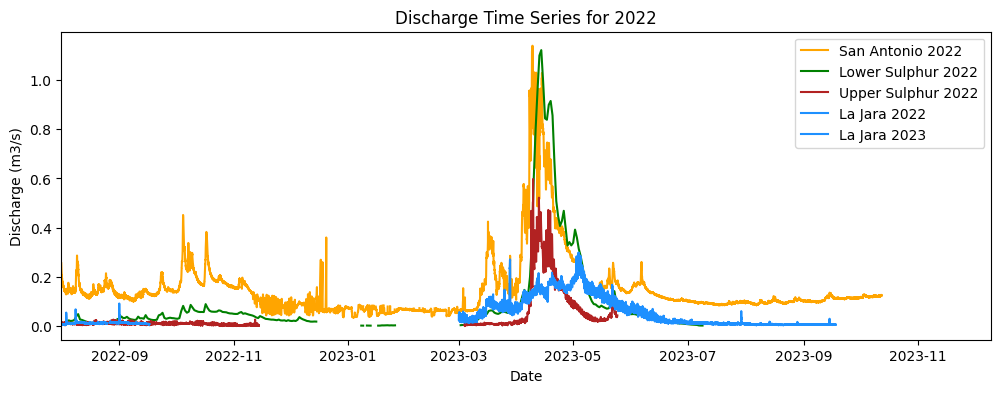

In [8]:
# plot discharge time series for all 4 sites
# 2022
plt.figure(figsize=(12, 4))
plt.plot(san_antonio.index, san_antonio['san_antonio (m3/s)'], label='San Antonio 2022', color='orange')
plt.plot(lower_sulphur.index, lower_sulphur['lower_sulphur (m3/s)'], label='Lower Sulphur 2022', color='green')
plt.plot(upper_sulphur.index, upper_sulphur['upper_sulphur (m3/s)'], label='Upper Sulphur 2022', color='firebrick')
plt.plot(lajara_2022.index, lajara_2022['la_jara'], label='La Jara 2022', color='dodgerblue')
plt.plot(lajara_2023.index, lajara_2023['la_jara'], label='La Jara 2023', color= 'dodgerblue')
plt.title('Discharge Time Series for 2022')
plt.xlabel('Date')
plt.ylabel('Discharge (m3/s)')
plt.xlim(pd.Timestamp('2022-08-01'), pd.Timestamp('2023-12-10'))
plt.legend()
plt.show()